## Carregamento e Visualização

In [28]:
import datetime
import traceback
from typing import Dict, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# FUNCOES DE CARREGAMENTO E PRE-PROCESSAMENTO
# ============================================================

column_types = Union[
    type[datetime.datetime], type[float], type[int], type[np.float64], type[np.int64]
]


def preprocessamento(
    df: pd.DataFrame, name: str, column_dtypes: Dict[str, Dict[str, column_types]]
) -> pd.DataFrame:
    """Remove linhas com NaN e valores invalidos, mostra a porcentagem removida."""
    try:
        dtype_map: Dict[str, column_types] = column_dtypes.get(
            name.lower(), column_dtypes.get(name, {})
        )

        df_clean = df.copy()
        df_clean["Date"] = pd.to_datetime(
            df_clean["Date"], errors="coerce", dayfirst=True
        )

        df_clean = df_clean.set_index("Date")
        daily_index = pd.date_range(
            start=df_clean.index[0], end=df_clean.index[-1], freq="D"
        )
        df_clean = df_clean.reindex(daily_index)
        df_clean.index.name = "Date"

        for col, target_dtype in dtype_map.items():
            if col not in df_clean.columns:
                print(f"  Aviso: coluna '{col}' nao encontrada em {name}.")
                continue

            if target_dtype is datetime.datetime:
                df_clean[col] = pd.to_datetime(
                    df_clean[col], errors="coerce", dayfirst=True
                )
            elif target_dtype in (int, np.int64):
                numeric = pd.to_numeric(df_clean[col], errors="coerce")
                df_clean[col] = numeric.astype("Int64")
            elif target_dtype in (float, np.float64):
                numeric = pd.to_numeric(df_clean[col], errors="coerce")
                df_clean[col] = numeric.astype("float64")
            else:
                # Fallback seguro para tipos nao numericos
                value_as_object = df_clean[col].astype("object")
                df_clean[col] = value_as_object

        rows_before: int = len(df_clean)
        total = rows_before
        rows_after: int = len(df_clean)

        if rows_before > 0:
            removed: int = rows_before - rows_after
            percentage: float = (removed / rows_before) * 100
            valid_rows = total - float(df_clean.count().item())

            print(f"\n{name}:")
            print(f"  Linhas antes: {len(df)}")
            print(f"  Linhas apos equalizacao de intervalos: {rows_after}")
            print(f"  Linhas removidas: {removed}")
            print(f"  Linhas nulas: {round(valid_rows / total * 100, 2)} %")
            print(f"  Percentual removido: {percentage:.2f}%")

    except Exception as e:
        traceback.print_exc()
        raise e
    return df_clean


# ============================================================
# EXECUCAO PRINCIPAL
# ============================================================

file_path = "data/cotacao_dolar_2006_2026.csv"  # PEGADO DE https://www3.bcb.gov.br/sgspub/consultarvalores/consultarValoresSeries.do?method=consultarValores

# mapa de dtypes pra nomes de coluna
convert_dtypes: Dict[str, Dict[str, column_types]] = {
    "dolar": {"Date": datetime.datetime, "Cotação USD-BRL": float}
}

dataset: pd.DataFrame = pd.read_csv(file_path, header="infer", sep=";")

# Aplicar dropna e mostrar porcentagem removida
print("\n" + "=" * 60)
print("PRÉ-PROCESSAMENTO:\n\n")
print("ANALISE DE VALORES FALTANTES (dropna)")
print("=" * 60)

name = "dolar"
dataset = preprocessamento(dataset, name.upper(), convert_dtypes)

# Mostrar estatisticas descritivas
dataset.describe(include="all")

# Preparar dados para analise anual
print("\n" + "=" * 60)
print("PREPARANDO DADOS PARA ANALISE ANUAL")
print("=" * 60)

print(f"NAME: {name}")
print(dataset.head(5))


PRÉ-PROCESSAMENTO:


ANALISE DE VALORES FALTANTES (dropna)
  Aviso: coluna 'Date' nao encontrada em DOLAR.

DOLAR:
  Linhas antes: 5020
  Linhas apos equalizacao de intervalos: 7306
  Linhas removidas: 0
  Linhas nulas: 31.29 %
  Percentual removido: 0.00%

PREPARANDO DADOS PARA ANALISE ANUAL
NAME: dolar
            Cotação USD-BRL
Date                       
2006-04-06           2.1299
2006-04-07           2.1409
2006-04-08              NaN
2006-04-09              NaN
2006-04-10           2.1522


## Optando por agregar valores por semana (evitar erros de dias vazios)

In [29]:
def agregacao_semanal(df: pd.DataFrame) -> pd.DataFrame:
    """Agrega um DataFrame temporal para frequencia semanal mantendo indice Date."""
    df_week = df.copy()

    if "Date" in df_week.columns:
        df_week["Date"] = pd.to_datetime(
            df_week["Date"], errors="coerce", dayfirst=True
        )
        df_week = df_week.dropna(subset=["Date"]).set_index("Date")

    if not isinstance(df_week.index, pd.DatetimeIndex):
        converted = pd.to_datetime(df_week.index, errors="coerce")
        df_week = df_week.loc[converted.notna()].copy()
        df_week.index = converted[converted.notna()]

    df_week = df_week.sort_index()

    # Agrega valores numericos por semana
    weekly = df_week.resample("W").mean(numeric_only=True)

    # Mantem um indice semanal regular entre min e max
    weekly_index = pd.date_range(
        start=weekly.index.min(), end=weekly.index.max(), freq="W"
    )
    weekly = weekly.reindex(weekly_index)
    weekly.index.name = "Date"

    return weekly


dataset = agregacao_semanal(dataset)
print(dataset.head())

            Cotação USD-BRL
Date                       
2006-04-09          2.13540
2006-04-16          2.14260
2006-04-23          2.12535
2006-04-30          2.11334
2006-05-07          2.06695


## Plotando série temporal e histograma


PLOTANDO SERIES TEMPORAIS


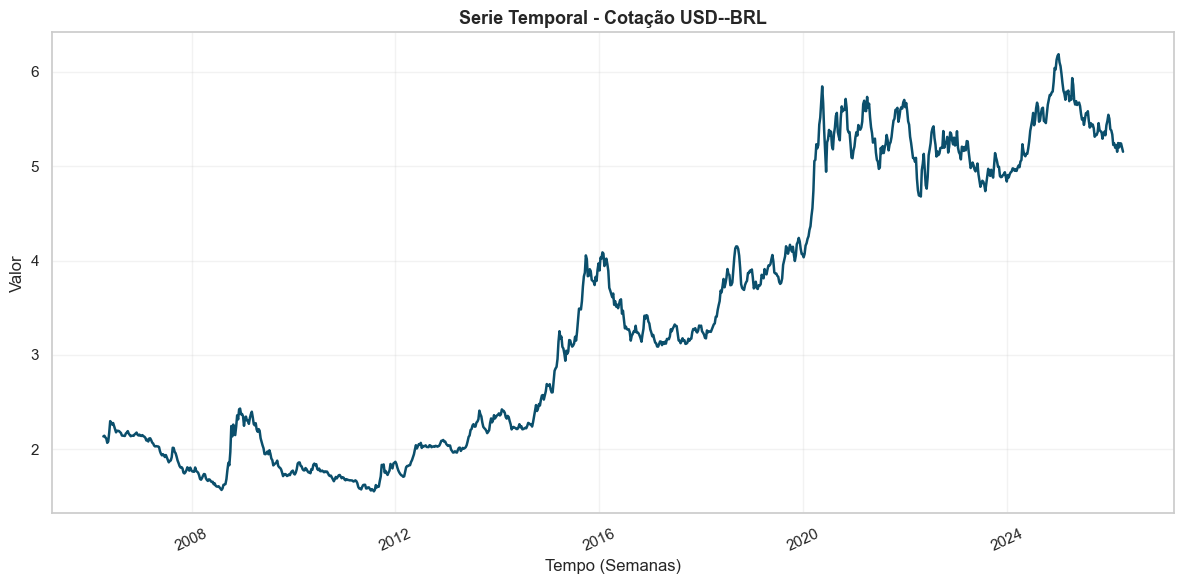


PLOTANDO HISTOGRAMAS


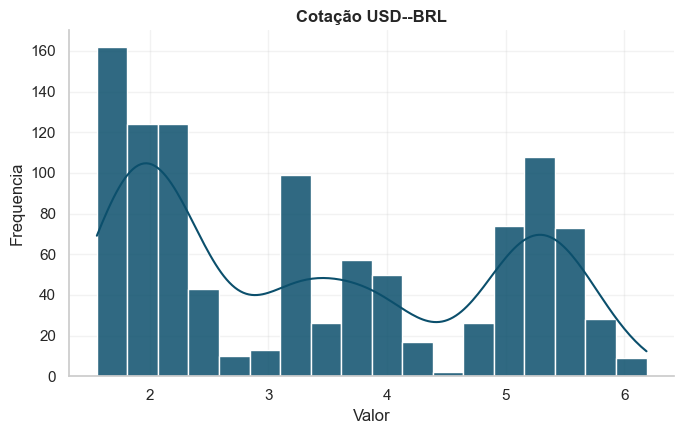


PLOTANDO TABELA DE RESUMO ESTATISTICO


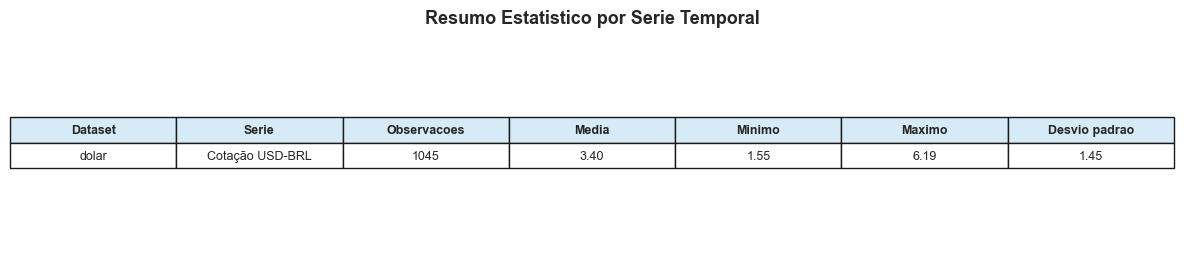

In [30]:
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import seaborn as sns


# ============================================================
# FUNCOES DE VISUALIZACAO
# ============================================================

def _prepare_for_time_plot(df: pd.DataFrame) -> pd.DataFrame:
    """Prepara DataFrame para plot temporal usando Date/Ano quando disponivel."""
    plot_df = df.copy()

    if "Date" in plot_df.columns:
        plot_df["Date"] = pd.to_datetime(plot_df["Date"], errors="coerce", dayfirst=True)
        plot_df = plot_df.dropna(subset=["Date"]).set_index("Date")
    elif "Ano" in plot_df.columns:
        ano = pd.to_numeric(plot_df["Ano"], errors="coerce")
        plot_df = plot_df.loc[ano.notna()].copy()
        plot_df["Ano"] = ano.loc[ano.notna()].astype(int).astype(str)
        plot_df = plot_df.set_index(pd.to_datetime(plot_df["Ano"], format="%Y", errors="coerce"))
        plot_df = plot_df.drop(columns=["Ano"], errors="ignore")

    if isinstance(plot_df.index, pd.PeriodIndex):
        plot_df.index = plot_df.index.to_timestamp()
    elif not isinstance(plot_df.index, pd.DatetimeIndex):
        converted_index = pd.to_datetime(plot_df.index, errors="coerce")
        valid_mask = np.asarray(converted_index.notna(), dtype=bool)
        if int(valid_mask.sum()) > 0:
            plot_df = plot_df.loc[valid_mask].copy()
            plot_df.index = converted_index[valid_mask]

    numeric_df = plot_df.select_dtypes(include=[np.number]).copy()
    return numeric_df.sort_index()


def plot_time_series(
    df: pd.DataFrame,
    title: str = "Serie Temporal",
    colors: Optional[List[str]] = None,
) -> None:
    """Plota serie temporal de um unico DataFrame com estilo Seaborn."""
    default_colors: List[str] = ["tab:blue", "tab:orange", "tab:green"]
    plot_df = _prepare_for_time_plot(df)

    if plot_df.empty:
        _, ax = plt.subplots(figsize=(12, 6))
        ax.set_title(f"{title} (sem colunas numericas)")
        ax.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()
        return

    long_df = plot_df.reset_index().melt(
        id_vars=[plot_df.index.name or "index"],
        var_name="Serie",
        value_name="Valor",
    )
    tempo_col = long_df.columns[0]
    long_df = long_df.rename(columns={tempo_col: "Tempo"})

    fig, ax = plt.subplots(figsize=(12, 6))

    if plot_df.shape[1] == 1:
        color = colors[0] if colors and len(colors) > 0 else default_colors[0]
        sns.lineplot(
            data=long_df,
            x="Tempo",
            y="Valor",
            linewidth=1.8,
            color=color,
            ax=ax,
        )
    else:
        palette = colors if colors else default_colors
        sns.lineplot(
            data=long_df,
            x="Tempo",
            y="Valor",
            hue="Serie",
            linewidth=2.0,
            palette=palette,
            ax=ax,
        )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Tempo (Semanas)")
    ax.set_ylabel("Valor")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_histograms(
    df: pd.DataFrame,
    title: str = "Histograma",
    color: str = "tab:blue",
) -> None:
    """Plota histograma de um unico DataFrame com estilo Seaborn."""
    numeric_df = df.select_dtypes(include=[np.number]).copy()

    _, ax = plt.subplots(figsize=(7, 4.5))

    if numeric_df.empty:
        ax.set_title(f"{title} (sem valores numericos)", fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()
        return

    values = numeric_df.to_numpy(dtype=float).ravel()
    values = values[~np.isnan(values)]
    sns.histplot(values, bins=18, kde=True, color=color, edgecolor="white", alpha=0.85, ax=ax)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frequencia")
    ax.grid(True, alpha=0.25)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()


def plot_summary_tables(
    df: pd.DataFrame,
    dataset_name: str = "dataset",
) -> None:
    """Plota tabela com estatisticas separadas por serie temporal de um unico DataFrame."""
    numeric_df = df.select_dtypes(include=[np.number])
    stats_rows: List[Dict[str, object]] = []

    if numeric_df.empty:
        stats_rows.append(
            {
                "Dataset": dataset_name,
                "Serie": "sem dados numericos",
                "Observacoes": 0,
                "Media": np.nan,
                "Minimo": np.nan,
                "Maximo": np.nan,
                "Desvio padrao": np.nan,
            }
        )
    elif isinstance(numeric_df.index, pd.MultiIndex) and numeric_df.index.nlevels > 1:
        first_numeric_col = numeric_df.columns[0]
        wide_df = numeric_df[first_numeric_col].unstack(level=1)
        for col in wide_df.columns:
            serie_vals = wide_df[col].dropna()
            if serie_vals.empty:
                obs = 0
                media = minimo = maximo = desvio = np.nan
            else:
                obs = int(serie_vals.count())
                media = float(serie_vals.mean())
                minimo = float(serie_vals.min())
                maximo = float(serie_vals.max())
                desvio = float(serie_vals.std())
            stats_rows.append(
                {
                    "Dataset": dataset_name,
                    "Serie": str(col),
                    "Observacoes": obs,
                    "Media": media,
                    "Minimo": minimo,
                    "Maximo": maximo,
                    "Desvio padrao": desvio,
                }
            )
    else:
        for col in numeric_df.columns:
            serie_vals = numeric_df[col].dropna()
            if serie_vals.empty:
                obs = 0
                media = minimo = maximo = desvio = np.nan
            else:
                obs = int(serie_vals.count())
                media = float(serie_vals.mean())
                minimo = float(serie_vals.min())
                maximo = float(serie_vals.max())
                desvio = float(serie_vals.std())
            stats_rows.append(
                {
                    "Dataset": dataset_name,
                    "Serie": str(col),
                    "Observacoes": obs,
                    "Media": media,
                    "Minimo": minimo,
                    "Maximo": maximo,
                    "Desvio padrao": desvio,
                }
            )

    stats_df = pd.DataFrame(stats_rows)
    display_df = stats_df.copy()

    for col in ["Media", "Minimo", "Maximo", "Desvio padrao"]:
        display_df[col] = display_df[col].map(lambda x: f"{x:.2f}" if pd.notna(x) else "NaN")

    _, ax = plt.subplots(figsize=(12, 0.9 * len(display_df) + 1.8))
    ax.axis("off")

    table = ax.table(
        cellText=display_df.values.tolist(),
        colLabels=display_df.columns.tolist(),
        cellLoc="center",
        loc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.6)

    for (row, _), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#D6EAF8")

    ax.set_title("Resumo Estatistico por Serie Temporal", fontsize=13, fontweight="bold", pad=14)
    plt.tight_layout()
    plt.show()


print("\n" + "=" * 60)
print("PLOTANDO SERIES TEMPORAIS")
print("=" * 60)
plot_time_series(
    dataset,
    title="Serie Temporal - Cotação USD--BRL",
    colors=["#0B4F6C", "#D1495B", "#2A9D8F"],
)

# Plotar histogramas
print("\n" + "=" * 60)
print("PLOTANDO HISTOGRAMAS")
print("=" * 60)
plot_histograms(
    dataset,
    title="Cotação USD--BRL",
    color="#0B4F6C",
)

# Plotar tabela com estatisticas resumo
print("\n" + "=" * 60)
print("PLOTANDO TABELA DE RESUMO ESTATISTICO")
print("=" * 60)
plot_summary_tables(dataset, dataset_name="dolar")

## Análise da série

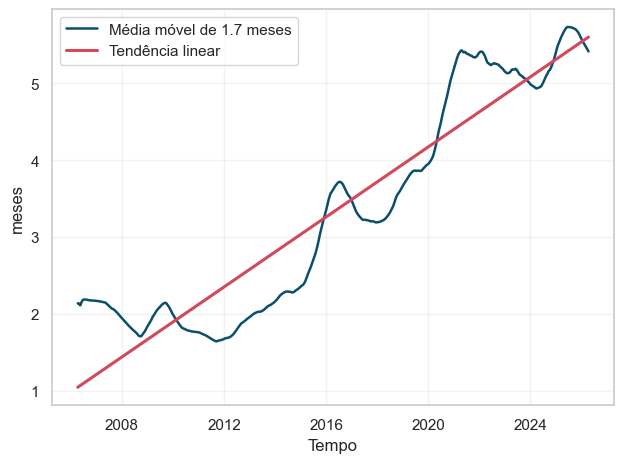

In [31]:
from pandas import PeriodIndex
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

def calc_stats(df):
    window = int(360/7) #indice esta em dias, logo isso da 1/7 ano
    # pd.Series(list(df.rolling(window)))
    tend = df.iloc[:, 0].astype(float).rolling(window=window, min_periods=1).mean()

    period_idx: PeriodIndex = PeriodIndex(dolar_df.index, freq="D")
    tend.index = period_idx.to_timestamp()

    if window//360 < 1:
        window = round(window/30, 1)
        label = "meses"
    else:
        window = window//360
        label = "anos"

    fig, ax = plt.subplots(1,1)
    ax.set_xlabel("Ano")
    ax.set_ylabel("USD-BRL (em Reais)")
    ax.grid(True, alpha=0.3)

    x = tend.index.map(pd.Timestamp.toordinal).to_numpy(dtype=float).reshape(-1, 1)
    y = tend.to_numpy(dtype=float)

    model = LinearRegression()
    model.fit(x, y)

    y_pred = model.predict(x)

    sns.lineplot(x=tend.index, y=tend, ax=ax, label=f"Média móvel de {window} {label}", color="#0B4F6C", linewidth=1.8)
    sns.lineplot(x=tend.index, y=y_pred, ax=ax, label="Tendência linear", color="#D1495B", linewidth=2.2)

    sns.set_theme(style="whitegrid")

    ax.set_xlabel("Tempo")
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_regressao_linear_intervalo_total(
    df: pd.DataFrame,
    value_col: str = "Cotação USD-BRL"
 ) :
    """Plota a serie e a regressao linear usando todo o intervalo temporal."""
    work_df = df.copy()

    if value_col not in work_df.columns:
        numeric_cols = work_df.select_dtypes(include=[np.number]).columns.tolist()
        if not numeric_cols:
            raise ValueError("Nao existem colunas numericas para regressao linear.")
        value_col = numeric_cols[0]

    series = pd.to_numeric(work_df[value_col], errors="coerce").dropna()
    if series.empty:
        raise ValueError("Serie vazia apos limpeza; nao foi possivel ajustar regressao.")
    x = series.index.map(pd.Timestamp.toordinal).to_numpy(dtype=float).reshape(-1, 1)
    y = series.to_numpy(dtype=float)

    model = LinearRegression()
    model.fit(x, y)

    y_pred = model.predict(x)

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(x=series.index, y=y, ax=ax, label="Serie observada", color="#0B4F6C", linewidth=1.8)
    sns.lineplot(x=series.index, y=y_pred, ax=ax, label="Regressao linear", color="#D1495B", linewidth=2.2)

    ax.set_title("Linha de tendência do intervalo total", fontsize=13, fontweight="bold")
    ax.set_xlabel("Tempo")
    ax.set_ylabel(value_col)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    return model

dolar_df: pd.DataFrame = dataset

# dolar_index: PeriodIndex = PeriodIndex(dolar_df.index, freq="")
# print(dolar_index)

dolar_series: pd.Series = pd.Series(list(dolar_df.values))

def sazon(df: pd.DataFrame) -> None:
    _ = df

def estacionaria(df: pd.DataFrame) -> None:
    _ = df


calc_stats(dolar_df)
# tendencia = plot_regressao_linear_intervalo_total(dataset)

## Dickey-Fuller

In [35]:
from typing import cast

from statsmodels.tsa.stattools import adfuller

# Seleciona a série numérica principal
col = dolar_df.select_dtypes(include=[np.number]).columns[0]
serie = pd.to_numeric(dolar_df[col], errors="coerce").dropna()

# Teste Dickey-Fuller aumentado (ADF)
ADFResult = tuple[float, float, int, int, dict[str, float], float]
resultado_adf = cast(ADFResult, adfuller(serie, autolag="AIC"))

print("=== Teste Dickey-Fuller (ADF) ===")
print(f"Série: {col}")
print(f"Estatística ADF: {resultado_adf[0]:.6f}")
print(f"p-valor: {resultado_adf[1]:.6f}")
print(f"Lags usados: {resultado_adf[2]}")
print(f"Nº de observações: {resultado_adf[3]}")
print("Valores críticos:")
for k, v in resultado_adf[4].items():
    print(f"  {k}: {v:.6f}")

alpha = 0.05
if resultado_adf[1] < alpha:
    print("A série é estacionária.")
else:
    print("A série NÃO É estacionária.")

=== Teste Dickey-Fuller (ADF) ===
Série: Cotação USD-BRL
Estatística ADF: -0.591357
p-valor: 0.872923
Lags usados: 4
Nº de observações: 1040
Valores críticos:
  1%: -3.436653
  5%: -2.864323
  10%: -2.568252
A série NÃO É estacionária.


=== Série transformada por diferenciação de ordem 1 ===
Série: Cotação USD-BRL
Estatística ADF: -16.602000
p-valor: 0.000000
Lags usados: 3
Nº de observações: 1040
Valores críticos:
  1%: -3.436653
  5%: -2.864323
  10%: -2.568252

Conclusão: série transformada é estacionária.


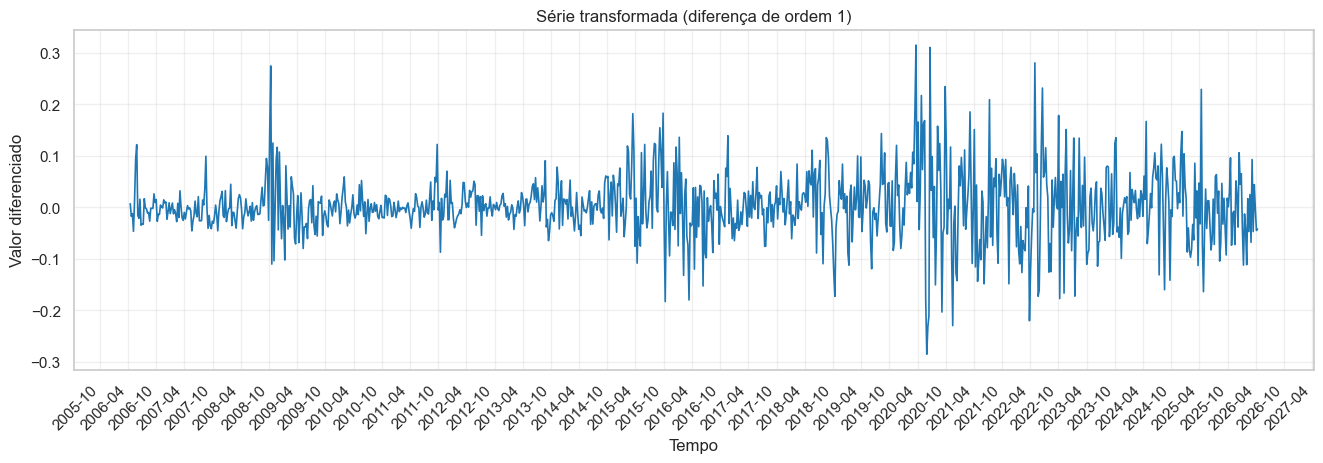

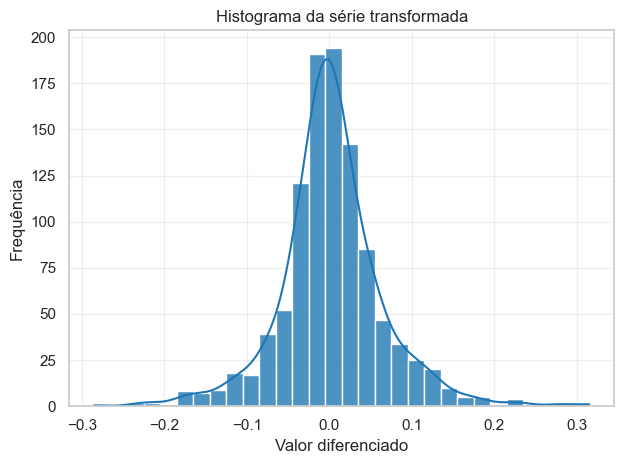

In [47]:
from typing import cast

from statsmodels.tsa.stattools import adfuller

# Série numérica base
col = dolar_df.select_dtypes(include=[np.number]).columns[0]
serie_base = pd.to_numeric(dolar_df[col], errors="coerce").dropna()

alpha = 0.05
ordem_escolhida = None
serie_transformada = None
resultado_adf_transformada = None

ADFResult = tuple[float, float, int, int, dict[str, float], float]

# Tenta diferenciação de ordem 1 e, se necessário, ordem 2
for ordem in [1, 2]:
    serie_diff = serie_base.diff(ordem).dropna()
    resultado = cast(ADFResult, adfuller(serie_diff, autolag="AIC"))

    if resultado[1] < alpha:
        ordem_escolhida = ordem
        serie_transformada = serie_diff
        resultado_adf_transformada = resultado
        break

# Caso não fique estacionária nem com ordem 2, mantém ordem 2 para relatório
if serie_transformada is None:
    ordem_escolhida = 2
    serie_transformada = serie_base.diff(2).dropna()
    resultado_adf_transformada = cast(ADFResult, adfuller(serie_transformada, autolag="AIC"))

assert serie_transformada is not None
assert resultado_adf_transformada is not None

print(f"=== Série transformada por diferenciação de ordem {ordem_escolhida} ===")
print(f"Série: {col}")
print(f"Estatística ADF: {resultado_adf_transformada[0]:.6f}")
print(f"p-valor: {resultado_adf_transformada[1]:.6f}")
print(f"Lags usados: {resultado_adf_transformada[2]}")
print(f"Nº de observações: {resultado_adf_transformada[3]}")
print("Valores críticos:")
for k, v in resultado_adf_transformada[4].items():
    print(f"  {k}: {v:.6f}")

if resultado_adf_transformada[1] < alpha:
    print("\nConclusão: série transformada é estacionária.")
else:
    print("\nConclusão: a série transformada não é estacionária nas transformações de ordem 1 e 2.")

import matplotlib.dates as mdates

x_vals = pd.to_datetime(serie_transformada.index, errors="coerce")
y_vals = pd.to_numeric(serie_transformada, errors="coerce").to_numpy(dtype=float)

fig, ax1 = plt.subplots(1, 1, figsize=(16, 5))

# Série temporal transformada
ax1.plot(x_vals.to_pydatetime(), y_vals, color="tab:blue", linewidth=1.2)
ax1.set_title(f"Série transformada (diferença de ordem {ordem_escolhida})")
ax1.set_xlabel("Tempo")
ax1.set_ylabel("Valor diferenciado")
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.grid(alpha=0.3)
fig.autofmt_xdate(rotation=45)
plt.show()
plt.close()

fig, ax2 = plt.subplots(1)

# Histograma da série transformada
y_hist = y_vals[~np.isnan(y_vals)]
sns.histplot(y_hist, bins=30, kde=True, color="tab:blue", alpha=0.8, edgecolor="white")
ax2.set_title("Histograma da série transformada")
ax2.set_xlabel("Valor diferenciado")
ax2.set_ylabel("Frequência")
ax2.grid(alpha=0.3)


plt.tight_layout()
plt.show()